In [4]:
#필요 라이브러리
!pip install scikit-learn pandas numpy seaborn matplotlib

In [3]:
#데이터 불러오기
from sklearn.datasets import fetch_openml
X,y=fetch_openml('adult',version=2, as_frame=True, return_X_y=True)

In [5]:
#데이터 기본 전처리
import pandas as pd
df=X.copy()
df['income']=y
df=df[['age','workclass','education','education-num','marital-status','occupation',
       'race','sex','capital-gain','capital-loss','hours-per-week','income']]
df=df.dropna()


[PMF of workclass]
workclass
Private             0.736559
Self-emp-not-inc    0.083896
Local-gov           0.068125
State-gov           0.043034
Self-emp-inc        0.036821
Federal-gov         0.031108
Without-pay         0.000456
Never-worked        0.000000
Name: proportion, dtype: float64


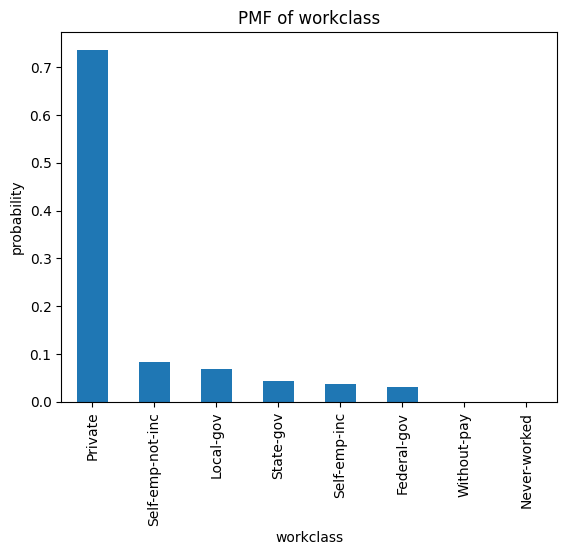

In [ ]:
#확률질량함수(PMF: Probability Mass Function): 고용 형태
import matplotlib.pyplot as plt

print('\n[PMF of workclass]')
workclass_dist=df['workclass'].value_counts(normalize=True) #value_counts()->각 항목이 몇 번 등장하는지 세기 
print(workclass_dist)                                       #normalize=True->전체 개수에서 해당 항목이 차지하는 비율(확률) 계산


plt.figure() #흰 바탕 만들기
workclass_dist.plot(kind='bar') #막대 그래프
plt.title('PMF of workclass')
plt.ylabel('probability')
plt.xticks(rotation=90) #항목 이름 90도 회전->세로로 표시
plt.show()

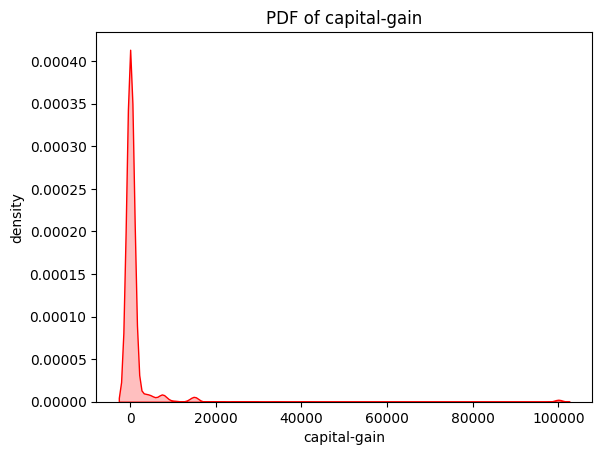

In [ ]:
#확률밀도함수: 자본 이득
import seaborn as sns

sns.kdeplot(df['capital-gain'],color='red', fill=True) #kdeplot->확률밀도함수
plt.title('PDF of capital-gain')
plt.xlabel('capital-gain')
plt.ylabel('density')
plt.show()

In [ ]:
#결합확률: 직업과 수입
joint_prob=pd.crosstab(df['occupation'], df['income'], normalize='all')

print('\n[결합확률표 P(occupation, income)]')
print(joint_prob)

print('\n결합확률의 전체 합:',joint_prob.to_numpy().sum())


[결합확률표 P(occupation, income)]
income                <=50K      >50K
occupation                           
Adm-clerical       0.105207  0.016684
Armed-Forces       0.000217  0.000109
Craft-repair       0.102731  0.030044
Exec-managerial    0.069037  0.063172
Farming-fishing    0.028610  0.003758
Handlers-cleaners  0.042013  0.002998
Machine-op-inspct  0.057567  0.008081
Other-service      0.102513  0.004432
Priv-house-serv    0.005192  0.000065
Prof-specialty     0.073599  0.060478
Protective-serv    0.014663  0.006691
Sales              0.087524  0.032042
Tech-support       0.022288  0.009124
Transport-moving   0.040710  0.010449

결합확률의 전체 합: 1.0


In [ ]:
#공분산(Covariance)과 상관계수(Correlation): 나이와 주당 근로시간
numeric_df=df[['age','hours-per-week']]

cov_matrix=numeric_df.cov() #numeric_df.cov->공분산 행렬
corr_matrix=numeric_df.corr() #numeric_df.corr->상관계수 행렬

print('\n[공분산 행렬]')
print(cov_matrix)

print('\n[상관계수 행렬]')
print(corr_matrix)


[공분산 행렬]
                       age  hours-per-week
age             174.352685       16.206246
hours-per-week   16.206246      144.265782

[상관계수 행렬]
                     age  hours-per-week
age             1.000000        0.102185
hours-per-week  0.102185        1.000000
